<a href="https://colab.research.google.com/github/shahankit82/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

part-3-nlp-sequence-modeling

Task 1: Dataset Understanding

Code

In [16]:
import pandas as pd

df = pd.read_csv('/content/customer_support_text_classification.csv')

print("Shape:", df.shape)
df.head()

Shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Explore dataset

In [17]:
# Columns
print(df.columns)

# Target distribution
df['sentiment_label'].value_counts()

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


,count
sentiment_label,
neutral,524
negative,497
positive,479


Sample text

In [18]:
df['customer_message'].sample(5)

,customer_message
153,The refund process was fast and convenient. My...
406,Can someone explain the difference between the...
1133,The refund process was fast and convenient. I ...
1202,The delivery was late and the package arrived ...
739,I am satisfied with the plan and would recomme...


Average text length

In [19]:
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))
print("Average length:", df['text_length'].mean())

Average length: 12.722666666666667


Class distribution plot

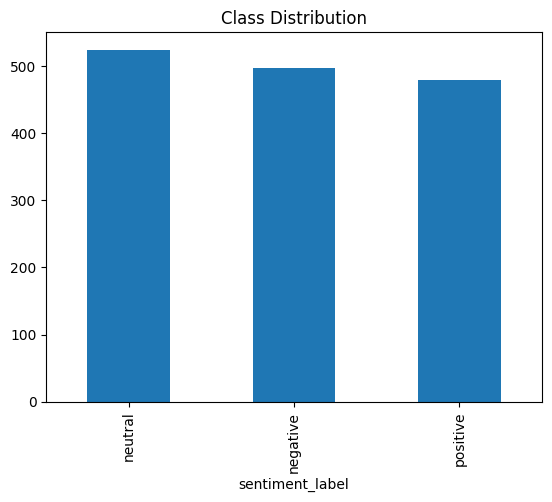

In [20]:
import matplotlib.pyplot as plt

df['sentiment_label'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

Task 2: Text Preprocessing

In [21]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove symbols
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['customer_message'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Task 3: Text Vectorization

TF-IDF

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment_label']

Task 4: Baseline Model
Logistic Regression

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       100
     neutral       1.00      1.00      1.00       116
    positive       1.00      1.00      1.00        84

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Save evaluation results

In [25]:
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.to_csv("model_evaluation.csv")

Task 5: Sequence Model (LSTM)

Tokenization


In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_seq = pad_sequences(sequences, maxlen=100)

y = pd.get_dummies(df['sentiment_label']).values

Train/Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.2)

LSTM Model

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.6583 - loss: 1.0214 - val_accuracy: 0.9000 - val_loss: 0.7883
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8479 - loss: 0.6441 - val_accuracy: 0.9500 - val_loss: 0.3404
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9823 - loss: 0.1750 - val_accuracy: 1.0000 - val_loss: 0.0636
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0057


Task 6: Attention & Transformers

Why RNN struggles:

Long sequences → vanishing gradients
Earlier words forgotten

How LSTM helps:

Memory cells store important info
Gates control information flow

What attention solves:

Focuses on important words dynamically
Improves sequence-to-sequence tasks

Why transformers matter:

No recurrence → faster training
Parallel processing
Used in modern AI systems

In [32]:
import os

# Create the directory if it doesn't exist
os.makedirs("results", exist_ok=True)

with open("results/sample_predictions.txt", "w") as f:
    for i in range(10):
        f.write(f"Text: {df['customer_message'].iloc[i]}\n")
        f.write(f"Prediction: {y_pred[i]}\n\n")